# Encrypted Logistic Regression with Concrete-ML (SGDClassifier)

This notebook explores Fully Homomorphic Encryption (FHE) training using `concrete-ml`'s `SGDClassifier`. We train logistic regression models on a binary classification dataset while experimenting with:

- Top-N important features
- Different parameter ranges
- Different maximum epochs

### Import the dataset

In [1]:
import pandas as pd
import numpy as np
import random
import pandas as pd

file_path = "/home/ccs-lab-f13/VanshFHE/SGDTrain/df_final_strategic.csv" 
df = pd.read_csv(file_path)
print(df.shape)
df.head()


(307511, 364)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,POS_SK_DPD_DEF_SUM,NAME_CONTRACT_STATUS_Active_x,NAME_CONTRACT_STATUS_Amortized debt,NAME_CONTRACT_STATUS_Approved_y,NAME_CONTRACT_STATUS_Canceled_y,NAME_CONTRACT_STATUS_Completed_x,NAME_CONTRACT_STATUS_Demand_x,NAME_CONTRACT_STATUS_Returned to the store,NAME_CONTRACT_STATUS_Signed_x,NAME_CONTRACT_STATUS_XNA
0,100002,1,0,0,1,0,202500.0,406597.5,24700.5,351000.0,...,0.0,1.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0
1,100003,0,0,0,0,0,270000.0,1293502.5,35698.5,1129500.0,...,0.0,0.928571,0.0,0.0,0.0,0.071429,0.0,0.000000,0.000000,0.0
2,100004,0,1,1,1,0,67500.0,135000.0,6750.0,135000.0,...,0.0,0.750000,0.0,0.0,0.0,0.250000,0.0,0.000000,0.000000,0.0
3,100006,0,0,0,1,0,135000.0,312682.5,29686.5,297000.0,...,0.0,0.857143,0.0,0.0,0.0,0.095238,0.0,0.047619,0.000000,0.0
4,100007,0,0,0,1,0,121500.0,513000.0,21865.5,513000.0,...,0.0,0.939394,0.0,0.0,0.0,0.045455,0.0,0.000000,0.015152,0.0


### Feature Importance based on Logistic Regression

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Separate the features and target
X = df.drop('TARGET', axis=1)  
y = df['TARGET']               

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
print("Training Logistic Regression for feature importance...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Feature importance = absolute value of coeffecients 
coefficients = np.abs(lr.coef_[0])

# Dataframe of feature and importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': coefficients
}).sort_values('importance', ascending=False)

print("Training completed!")


Features shape: (307511, 363)
Target shape: (307511,)
Training Logistic Regression for feature importance...
Training completed!


# Experimentation for different shapes of dataset

## Shape (2000, 100)

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt

# Top n features into a list
n_features = 100
top_features = feature_importance.head(n_features)['feature'].tolist()

# Selection of dataset for n features 
X_selected = df[top_features]
y = df['TARGET']

print(f"Selected {n_features} features")

# Class distribution of dataset (highly imbalance)
print(f"Original class distribution:")
# print(y.value_counts())
print(f"Original class ratio: {y.value_counts()[0]/y.value_counts()[1]:.1f}:1")


Selected 100 features
Original class distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64
Original class ratio: 11.4:1


In [20]:
# Positions of class 0 and class 1 in dataset
target_1_indices = y[y == 1].index
target_0_indices = y[y == 0].index

# Sample Creation; equal class distribution
n_samples_per_class = 1000
target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

# Concatenate and shuffle samples
balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
np.random.shuffle(balanced_indices)

X_balanced = X_selected.loc[balanced_indices]
y_balanced = y.loc[balanced_indices]

print("\nBalanced dataset:")
print(f"Shape: {X_balanced.shape}")
print("Class distribution:\n", y_balanced.value_counts())
print(f"Class ratio: {y_balanced.value_counts()[0]/y_balanced.value_counts()[1]:.1f}:1")



Balanced dataset:
Shape: (2000, 100)
Class distribution:
 TARGET
1    1000
0    1000
Name: count, dtype: int64
Class ratio: 1.0:1


In [23]:
# Train set: 80 %, test set: 20%
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

# Standard scaler 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")
print(f"Training class distribution:")
print(y_train.value_counts())

X_train_df = pd.DataFrame(X_train_scaled, columns=top_features)
print(np.min(X_train_scaled), np.max(X_train_scaled))


Training set: (1600, 100)
Test set: (400, 100)
Training class distribution:
TARGET
1    800
0    800
Name: count, dtype: int64
-27.198402655858956 38.16660311342295


In [24]:
# Range of features/target model will compile

parameters_range = (-30.0, 40.0)
print("parameters_range[0]:", parameters_range[0])  
print("parameters_range[1]:", parameters_range[1]) 

parameters_range[0]: -30.0
parameters_range[1]: 40.0


### setup training parameters for fit and compile 

In [25]:
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import time

config = Configuration(
    enable_unsafe_features=True, # Enables/Disable FHE features not safe for production
    use_insecure_key_cache=True, # Enable/Disable reusing keys
    insecure_key_cache_location="./keycache", # Key location
    fhe_execution=True #Enalbe/Disable FHE
)

cml_sgd = SGDClassifier(
    n_bits=16,                  # Bit-width for quantization of input features 
    fit_encrypted=True,         # Enables training under FHE constraints
    parameters_range = parameters_range, 
    loss="log_loss",            # loss function
    penalty="l2",               # Regularization paramteter (Ridge)
    alpha=0.01,                 # Regularization strength
    fit_intercept=True,         # Enalbe/Disable learning bias term
    max_iter=10,                # Maximum epochs
    tol=0.01,                   # Improvement factor threshold
    shuffle=True,               # Shuffle training data each epch
    verbose=True,               # Enalbe/Disable Training Progress
    n_jobs=None,                # no of parallel jobs
    random_state=42,            # seed for reproducebility
    learning_rate="adaptive",   # Learning rate schedule
    eta0=0.001,                 # Initial Learning Rate
    power_t=0.5,                # Exponent for inverse scaling of learning rate (not effective)
    early_stopping=True,        # Enalbe/Disable early stopping
    validation_fraction=0.1,    # Fraction of validation set
    n_iter_no_change=3,         # No of epochs without change to trigger early stop
    class_weight="balanced",    # Automatically adjust class weights for imbalanced dataset
    warm_start=False,           # Enable/Disable resuse of previous call
    average=False,              # Enable/Disable use of average weights
)

# Batch size of ciphertext in cml.sgd
batch_size = cml_sgd.batch_size
print(batch_size)

print("Training encrypted SGDClassifier...")
cml_sgd.fit(X_train_scaled, y_train, fhe="execute")

print("Weight range:", cml_sgd.coef_.min(), cml_sgd.coef_.max())

# Model compilation
cml_sgd.compile(X_train_scaled, configuration=config)


8
Training encrypted SGDClassifier...
Compiling training circuit on device 'cpu'...


RuntimeError: Unfeasible noise constraint encountered (see https://docs.zama.ai/concrete/compilation/common_errors#id-8.-unfeasible-noise-constraint): At location quantizers.py:717:0:
1σ²Br[1] + 1σ²Br[2] + 1σ²K[1→3] + 1σ²FK[2→1] + 1σ²M[3] < (2²)**-15.5 (12bits partition:3 count:1, dom=31).

The ciphertext noise budget is insufficient for parameter range (-30, 40)

# Shape (2000, 90)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

n_features = 90
top_features = feature_importance.head(n_features)['feature'].tolist()
X_selected = df[top_features]
y = df['TARGET']

print(f"Selected {n_features} features")
print(f"Original class distribution:")
print(y.value_counts())
print(f"Original class ratio: {y.value_counts()[0]/y.value_counts()[1]:.1f}:1")


Selected 90 features
Original class distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64
Original class ratio: 11.4:1


In [4]:
np.random.seed(42)

target_1_indices = y[y == 1].index
target_0_indices = y[y == 0].index

n_samples_per_class = 1000
target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
np.random.shuffle(balanced_indices)

X_balanced = X_selected.loc[balanced_indices]
y_balanced = y.loc[balanced_indices]

print("\nBalanced dataset:")
print(f"Shape: {X_balanced.shape}")
print("Class distribution:\n", y_balanced.value_counts())
print(f"Class ratio: {y_balanced.value_counts()[0]/y_balanced.value_counts()[1]:.1f}:1")



Balanced dataset:
Shape: (2000, 90)
Class distribution:
 TARGET
1    1000
0    1000
Name: count, dtype: int64
Class ratio: 1.0:1


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")
print(f"Training class distribution:")
print(y_train.value_counts())

X_train_df = pd.DataFrame(X_train_scaled, columns=top_features)
print(np.min(X_train_scaled), np.max(X_train_scaled))


Training set: (1600, 90)
Test set: (400, 90)
Training class distribution:
TARGET
1    800
0    800
Name: count, dtype: int64
-27.198402655858956 38.16660311342295


In [6]:
parameters_range = (-30.0, 40.0)
print("parameters_range[0]:", parameters_range[0])
print("parameters_range[1]:", parameters_range[1])  


parameters_range[0]: -30.0
parameters_range[1]: 40.0


In [7]:
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import time
config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache", 
    fhe_execution=True
)

cml_sgd = SGDClassifier(
    n_bits=16,                
    fit_encrypted=True,
    parameters_range = parameters_range, 
    loss="log_loss",
    penalty="l2",
    alpha=0.01,
    fit_intercept=True,
    max_iter=10,            
    tol=0.01,
    shuffle=True,
    verbose=True,
    n_jobs=None,
    random_state=42,
    learning_rate="adaptive",  
    eta0=0.001,                
    power_t=0.5,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=3,
    class_weight="balanced",
    warm_start=False,
    average=False,      
)

batch_size = cml_sgd.batch_size
print(batch_size)

print("Training encrypted SGDClassifier...")
cml_sgd.fit(X_train_scaled, y_train, fhe="execute")

print("Weight range:", cml_sgd.coef_.min(), cml_sgd.coef_.max())
cml_sgd.compile(X_train_scaled, configuration=config)


8
Training encrypted SGDClassifier...
Compiling training circuit on device 'cpu'...


RuntimeError: Unfeasible noise constraint encountered (see https://docs.zama.ai/concrete/compilation/common_errors#id-8.-unfeasible-noise-constraint): At location quantizers.py:717:0:
1σ²Br[1] + 1σ²Br[2] + 1σ²K[1→3] + 1σ²FK[2→1] + 1σ²M[3] < (2²)**-15.5 (12bits partition:3 count:1, dom=31).

The ciphertext noise budget is insufficient for parameter range (-30, 40). Therefore this is the maximum range beyond which our ciphertext becomes too noisy to compute homomorphically without lossing the decryption results

# Maximum (2000, 80) Parameter range (-30, 30)

## Experimentation 1: 

We try different Shape of our dataset. 
For each experiment we fix the no of sample, and evaluate for different no of features (40, 60 80). 
For each no of features, we evaulate threee parameter ranges (-15, 15){min range at shape (100, 40)}, 
(-21, 25) {subject to change as per choice} and (-30, 30) {max range at shape (2000, 80)}

### Shape (100, 40)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

# Select features, and parameter_ranges and no of samples in each class
feature_counts = [40, 60, 80]
parameter_ranges = [(-15, 15), (-21, 25), (-30, 30)]
n_samples_per_class = 50 

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

# Release memory
def release_memory():
    gc.collect()
    time.sleep(2) 

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)
        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted)
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 40 Features ======

---- Run with parameters_range = (-15, 15) ----
Confusion Matrix:
[[8 2]
 [6 4]]
Accuracy: 0.6000 | ROC AUC: 0.6000
Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.80      0.67        10
           1       0.67      0.40      0.50        10

    accuracy                           0.60        20
   macro avg       0.62      0.60      0.58        20
weighted avg       0.62      0.60      0.58        20


---- Run with parameters_range = (-21, 25) ----


KeySetCache: miss, regenerating ./keycache/8605362751802451323


Confusion Matrix:
[[6 4]
 [7 3]]
Accuracy: 0.4500 | ROC AUC: 0.4500
Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.60      0.52        10
           1       0.43      0.30      0.35        10

    accuracy                           0.45        20
   macro avg       0.45      0.45      0.44        20
weighted avg       0.45      0.45      0.44        20


---- Run with parameters_range = (-30, 30) ----


Parameter range (-30, 30)

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

n_features = 40
top_features = feature_importance.head(n_features)['feature'].tolist()
X_selected = df[top_features]
y = df['TARGET']

print(f"Selected {n_features} features")
print(f"Original class distribution:")
print(y.value_counts())
print(f"Original class ratio: {y.value_counts()[0]/y.value_counts()[1]:.1f}:1")


Selected 40 features
Original class distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64
Original class ratio: 11.4:1


In [5]:
np.random.seed(42)
target_1_indices = y[y == 1].index
target_0_indices = y[y == 0].index

n_samples_per_class = 50
target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
np.random.shuffle(balanced_indices)

X_balanced = X_selected.loc[balanced_indices]  
y_balanced = y.loc[balanced_indices]

print("\nBalanced dataset:")
print(f"Shape: {X_balanced.shape}")
print("Class distribution:\n", y_balanced.value_counts())
print(f"Class ratio: {y_balanced.value_counts()[0]/y_balanced.value_counts()[1]:.1f}:1")



Balanced dataset:
Shape: (100, 40)
Class distribution:
 TARGET
0    50
1    50
Name: count, dtype: int64
Class ratio: 1.0:1


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")
print(f"Training class distribution:")
print(y_train.value_counts())

X_train_df = pd.DataFrame(X_train_scaled, columns=top_features)
print(np.min(X_train_scaled), np.max(X_train_scaled))


Training set: (80, 40)
Test set: (20, 40)
Training class distribution:
TARGET
0    40
1    40
Name: count, dtype: int64
-8.888194417315589 7.1965194326648625


In [7]:
parameters_range = (-30.0, 30.0)

print("parameters_range[0]:", parameters_range[0]) 
print("parameters_range[1]:", parameters_range[1]) 


parameters_range[0]: -30.0
parameters_range[1]: 30.0


In [8]:
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import time
config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",  
    fhe_execution=True
)

cml_sgd = SGDClassifier(
    n_bits=16,                   
    fit_encrypted=True,
    parameters_range = parameters_range,
    loss="log_loss",
    penalty="l2",
    alpha=0.01,
    fit_intercept=True,
    max_iter=10,               
    tol=0.01,
    shuffle=True,
    verbose=True,
    n_jobs=None,
    random_state=42,
    learning_rate="adaptive",  
    eta0=0.001,                
    power_t=0.5,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=3,
    class_weight="balanced",
    warm_start=False,
    average=False,       
)

batch_size = cml_sgd.batch_size
print(batch_size)

print("Training encrypted SGDClassifier...")
cml_sgd.fit(X_train_scaled, y_train, fhe="execute")

print("Weight range:", cml_sgd.coef_.min(), cml_sgd.coef_.max())
cml_sgd.compile(X_train_scaled, configuration=config)


8
Training encrypted SGDClassifier...
Compiling training circuit on device 'cpu'...
Compilation took 2.9869 seconds.
Key Generation...
Key generation took 136.3660 seconds.
Training on encrypted data...
Iteration 0 took 45.75 seconds.
Iteration 1 took 33.93 seconds.
Iteration 2 took 32.98 seconds.
Iteration 3 took 33.72 seconds.
Iteration 4 took 33.22 seconds.
Iteration 5 took 34.14 seconds.
Iteration 6 took 33.68 seconds.
Iteration 7 took 33.97 seconds.
Iteration 8 took 33.49 seconds.
Iteration 9 took 33.71 seconds.
Weight range: -7.943068567891582 8.510430608455266


In [9]:
print("Running encrypted inference...")
y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")#

print("Prediction on  samples and Probability")
print(y_pred_encrypted)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_encrypted))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_encrypted))

print("\nROC AUC Score:")
print(roc_auc_score(y_test, y_pred_encrypted))


Running encrypted inference...


KeySetCache: miss, regenerating ./keycache/1092937450431504949


Prediction on  samples and Probability
[1 0 0 1 1 0 1 0 1 1 0 1 1 0 1 0 0 0 0 1]
Confusion Matrix:
[[4 6]
 [6 4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.40      0.40        10
           1       0.40      0.40      0.40        10

    accuracy                           0.40        20
   macro avg       0.40      0.40      0.40        20
weighted avg       0.40      0.40      0.40        20


ROC AUC Score:
0.39999999999999997


### Shape (100, 60) 

paramter range (-15, 15)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

n_features = 40
top_features = feature_importance.head(n_features)['feature'].tolist()
X_selected = df[top_features]
y = df['TARGET']

print(f"Selected {n_features} features")
print(f"Original class distribution:")
print(y.value_counts())
print(f"Original class ratio: {y.value_counts()[0]/y.value_counts()[1]:.1f}:1")


In [ ]:
target_1_indices = y[y == 1].index
target_0_indices = y[y == 0].index

n_samples_per_class = 50
target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
np.random.shuffle(balanced_indices)

X_balanced = X_selected.loc[balanced_indices]
y_balanced = y.loc[balanced_indices]

print("\nBalanced dataset:")
print(f"Shape: {X_balanced.shape}")
print("Class distribution:\n", y_balanced.value_counts())
print(f"Class ratio: {y_balanced.value_counts()[0]/y_balanced.value_counts()[1]:.1f}:1")


In [ ]:
# Split the balanced dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")
print(f"Training class distribution:")
print(y_train.value_counts())

X_train_df = pd.DataFrame(X_train_scaled, columns=top_features)
print(np.min(X_train_scaled), np.max(X_train_scaled))


In [9]:
print("Running encrypted inference...")
y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

print("Prediction on  samples and Probability")
print(y_pred_encrypted)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_encrypted))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_encrypted))

print("\nROC AUC Score:")
print(roc_auc_score(y_test, y_pred_encrypted))


Running encrypted inference...


KeySetCache: miss, regenerating ./keycache/1092937450431504949


Prediction on  samples and Probability
[1 0 0 1 1 0 1 0 1 1 0 1 1 0 1 0 0 0 0 1]
Confusion Matrix:
[[4 6]
 [6 4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.40      0.40        10
           1       0.40      0.40      0.40        10

    accuracy                           0.40        20
   macro avg       0.40      0.40      0.40        20
weighted avg       0.40      0.40      0.40        20


ROC AUC Score:
0.39999999999999997


### Shape (100, 60) 
parameter range(-21, 25)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [60]
parameter_ranges = [(-21, 25)]
n_samples_per_class = 50  

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(5)  

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted)
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 60 Features ======

---- Run with parameters_range = (-21, 25) ----


KeySetCache: miss, regenerating ./keycache/10529703201741377720


Confusion Matrix:
[[5 5]
 [7 3]]
Accuracy: 0.4000 | ROC AUC: 0.4000
Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.40      0.40        10
           1       0.40      0.40      0.40        10

    accuracy                           0.40        20
   macro avg       0.40      0.40      0.40        20
weighted avg       0.40      0.40      0.40        20


==== Final Results ====
Features: 60 | Parameters: (-21, 25) | AUC: 0.4000 | Accuracy: 0.4000


### Shape (100, 60) 
parameter (-30, 30)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [60]
parameter_ranges = [(-30, 30)]
n_samples_per_class = 50  

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(5)  

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted)
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 60 Features ======

---- Run with parameters_range = (-30, 30) ----


KeySetCache: miss, regenerating ./keycache/10529703201741377720


Confusion Matrix:
[[5 5]
 [7 3]]
Accuracy: 0.4000 | ROC AUC: 0.4000
Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.50      0.45        10
           1       0.38      0.30      0.33        10

    accuracy                           0.40        20
   macro avg       0.40      0.40      0.39        20
weighted avg       0.40      0.40      0.39        20


==== Final Results ====
Features: 60 | Parameters: (-30, 30) | AUC: 0.4000 | Accuracy: 0.4000


### Shape (100, 80)
parameter range (-15, 15)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time
import os

feature_counts = [80]
parameter_ranges = [(-15, 15), (-21, 25), (-30, 30)]
n_samples_per_class = 50

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    del X_train_scaled, X_test_scaled, X_train, X_test, y_train, y_test
    gc.collect()
    time.sleep(2)
    gc.collect()
    os.system("sync; echo 3 > /proc/sys/vm/drop_caches")

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted)
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 80 Features ======

---- Run with parameters_range = (-15, 15) ----


KeySetCache: miss, regenerating ./keycache/1655699760599805720


Confusion Matrix:
[[6 4]
 [4 6]]
Accuracy: 0.6000 | ROC AUC: 0.6000
Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.60      0.60        10
           1       0.60      0.60      0.60        10

    accuracy                           0.60        20
   macro avg       0.60      0.60      0.60        20
weighted avg       0.60      0.60      0.60        20



UnboundLocalError: local variable 'X_train_scaled' referenced before assignment

parameter range (-21, 25)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [80]
parameter_ranges = [(-21, 25), (-30, 30)]
n_samples_per_class = 50

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(5)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted)
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 80 Features ======

---- Run with parameters_range = (-21, 25) ----


KeySetCache: miss, regenerating ./keycache/6529064130947534851


Confusion Matrix:
[[6 4]
 [5 5]]
Accuracy: 0.5500 | ROC AUC: 0.5500
Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.60      0.57        10
           1       0.56      0.50      0.53        10

    accuracy                           0.55        20
   macro avg       0.55      0.55      0.55        20
weighted avg       0.55      0.55      0.55        20


---- Run with parameters_range = (-30, 30) ----


parameter range (-30, 30)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [80]
parameter_ranges = [((-30, 30))]
n_samples_per_class = 50

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted)
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 80 Features ======

---- Run with parameters_range = (-30, 30) ----
Confusion Matrix:
[[2 8]
 [3 7]]
Accuracy: 0.4500 | ROC AUC: 0.4500
Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.20      0.27        10
           1       0.47      0.70      0.56        10

    accuracy                           0.45        20
   macro avg       0.43      0.45      0.41        20
weighted avg       0.43      0.45      0.41        20


==== Final Results ====
Features: 80 | Parameters: (-30, 30) | AUC: 0.4500 | Accuracy: 0.4500


### Shape (250, 40)
parameter range (-15, 15)

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [40]
parameter_ranges = [(-15, 15)]
n_samples_per_class = 125

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted)
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 40 Features ======

---- Run with parameters_range = (-15, 15) ----


KeySetCache: miss, regenerating ./keycache/12522562931708622395


Confusion Matrix:
[[11 14]
 [12 13]]
Accuracy: 0.4800 | ROC AUC: 0.4800
Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.44      0.46        25
           1       0.48      0.52      0.50        25

    accuracy                           0.48        50
   macro avg       0.48      0.48      0.48        50
weighted avg       0.48      0.48      0.48        50


==== Final Results ====
Features: 40 | Parameters: (-15, 15) | AUC: 0.4800 | Accuracy: 0.4800


parameter range (-21, 25)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [40]
parameter_ranges = [(-21, 25), (-30, 30)]
n_samples_per_class = 125

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted)
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")


====== Using Top 40 Features ======

---- Run with parameters_range = (-21, 25) ----
Confusion Matrix:
[[14 11]
 [ 9 16]]
Accuracy: 0.6000 | ROC AUC: 0.6000
Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.56      0.58        25
           1       0.59      0.64      0.62        25

    accuracy                           0.60        50
   macro avg       0.60      0.60      0.60        50
weighted avg       0.60      0.60      0.60        50


---- Run with parameters_range = (-30, 30) ----


parameter range (-30, 30)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [40]
parameter_ranges = [(-30, 30)]
n_samples_per_class = 125

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted)
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 40 Features ======

---- Run with parameters_range = (-30, 30) ----


KeySetCache: miss, regenerating ./keycache/13436999170089905775


Confusion Matrix:
[[13 12]
 [18  7]]
Accuracy: 0.4000 | ROC AUC: 0.4000
Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.52      0.46        25
           1       0.37      0.28      0.32        25

    accuracy                           0.40        50
   macro avg       0.39      0.40      0.39        50
weighted avg       0.39      0.40      0.39        50


==== Final Results ====
Features: 40 | Parameters: (-30, 30) | AUC: 0.4000 | Accuracy: 0.4000


### Shape (250, 60)
parameter range (-15, 15) and (-21, 25)

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [60]
parameter_ranges = [(-15, 15), (-21, 25)]
n_samples_per_class = 125

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted)
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 60 Features ======

---- Run with parameters_range = (-15, 15) ----


KeySetCache: miss, regenerating ./keycache/15643122339127468621


Confusion Matrix:
[[17  8]
 [12 13]]
Accuracy: 0.6000 | ROC AUC: 0.6000
Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.68      0.63        25
           1       0.62      0.52      0.57        25

    accuracy                           0.60        50
   macro avg       0.60      0.60      0.60        50
weighted avg       0.60      0.60      0.60        50


---- Run with parameters_range = (-21, 25) ----


KeySetCache: miss, regenerating ./keycache/2897686312809962453


Confusion Matrix:
[[18  7]
 [13 12]]
Accuracy: 0.6000 | ROC AUC: 0.6000
Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.72      0.64        25
           1       0.63      0.48      0.55        25

    accuracy                           0.60        50
   macro avg       0.61      0.60      0.59        50
weighted avg       0.61      0.60      0.59        50


==== Final Results ====
Features: 60 | Parameters: (-15, 15) | AUC: 0.6000 | Accuracy: 0.6000
Features: 60 | Parameters: (-21, 25) | AUC: 0.6000 | Accuracy: 0.6000


parameter range (-30, 30)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [60]
parameter_ranges = [(-30, 30)]
n_samples_per_class = 125

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted)
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 60 Features ======

---- Run with parameters_range = (-30, 30) ----
Confusion Matrix:
[[ 6 19]
 [11 14]]
Accuracy: 0.4000 | ROC AUC: 0.4000
Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.24      0.29        25
           1       0.42      0.56      0.48        25

    accuracy                           0.40        50
   macro avg       0.39      0.40      0.38        50
weighted avg       0.39      0.40      0.38        50


==== Final Results ====
Features: 60 | Parameters: (-30, 30) | AUC: 0.4000 | Accuracy: 0.4000


### Shape (250, 80)
parameter range (-15, 15) (-21, 25)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [80]
parameter_ranges = [(-15, 15), (-21, 25)]
n_samples_per_class = 125

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted)
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 80 Features ======

---- Run with parameters_range = (-15, 15) ----


KeySetCache: miss, regenerating ./keycache/15719213143420437634


Confusion Matrix:
[[13 12]
 [19  6]]
Accuracy: 0.3800 | ROC AUC: 0.3800
Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.52      0.46        25
           1       0.33      0.24      0.28        25

    accuracy                           0.38        50
   macro avg       0.37      0.38      0.37        50
weighted avg       0.37      0.38      0.37        50


---- Run with parameters_range = (-21, 25) ----
Confusion Matrix:
[[14 11]
 [17  8]]
Accuracy: 0.4400 | ROC AUC: 0.4400
Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.56      0.50        25
           1       0.42      0.32      0.36        25

    accuracy                           0.44        50
   macro avg       0.44      0.44      0.43        50
weighted avg       0.44      0.44      0.43        50


==== Final Results ====
Features: 80 | Parameters: (-15, 15) | AUC: 0.3800 | Accuracy: 0.3800
Features: 80

parameter range (-30, 30)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [80]
parameter_ranges = [(-30, 30)]
n_samples_per_class = 125

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted)
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 80 Features ======

---- Run with parameters_range = (-30, 30) ----
Confusion Matrix:
[[11 14]
 [14 11]]
Accuracy: 0.4400 | ROC AUC: 0.4400
Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.44      0.44        25
           1       0.44      0.44      0.44        25

    accuracy                           0.44        50
   macro avg       0.44      0.44      0.44        50
weighted avg       0.44      0.44      0.44        50


==== Final Results ====
Features: 80 | Parameters: (-30, 30) | AUC: 0.4400 | Accuracy: 0.4400


## Shape (500, 40)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [40]
parameter_ranges = [(-15, 15), (-21, 25)]
n_samples_per_class = 250

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted)
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 40 Features ======

---- Run with parameters_range = (-15, 15) ----
Confusion Matrix:
[[28 22]
 [24 26]]
Accuracy: 0.5400 | ROC AUC: 0.5400
Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.56      0.55        50
           1       0.54      0.52      0.53        50

    accuracy                           0.54       100
   macro avg       0.54      0.54      0.54       100
weighted avg       0.54      0.54      0.54       100


---- Run with parameters_range = (-21, 25) ----


KeySetCache: miss, regenerating ./keycache/13165917544023794853


Confusion Matrix:
[[29 21]
 [26 24]]
Accuracy: 0.5300 | ROC AUC: 0.5300
Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.58      0.55        50
           1       0.53      0.48      0.51        50

    accuracy                           0.53       100
   macro avg       0.53      0.53      0.53       100
weighted avg       0.53      0.53      0.53       100


==== Final Results ====
Features: 40 | Parameters: (-15, 15) | AUC: 0.5400 | Accuracy: 0.5400
Features: 40 | Parameters: (-21, 25) | AUC: 0.5300 | Accuracy: 0.5300


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [40]
parameter_ranges = [(-30, 30)]
n_samples_per_class = 250

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted)
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 40 Features ======

---- Run with parameters_range = (-30, 30) ----
Confusion Matrix:
[[23 27]
 [29 21]]
Accuracy: 0.4400 | ROC AUC: 0.4400
Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.46      0.45        50
           1       0.44      0.42      0.43        50

    accuracy                           0.44       100
   macro avg       0.44      0.44      0.44       100
weighted avg       0.44      0.44      0.44       100


==== Final Results ====
Features: 40 | Parameters: (-30, 30) | AUC: 0.4400 | Accuracy: 0.4400


## Shape (500, 60)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [60]
parameter_ranges = [(-15, 15), (-21, 25)]
n_samples_per_class = 250

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted)
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 60 Features ======

---- Run with parameters_range = (-15, 15) ----
Confusion Matrix:
[[24 26]
 [30 20]]
Accuracy: 0.4400 | ROC AUC: 0.4400
Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.48      0.46        50
           1       0.43      0.40      0.42        50

    accuracy                           0.44       100
   macro avg       0.44      0.44      0.44       100
weighted avg       0.44      0.44      0.44       100


---- Run with parameters_range = (-21, 25) ----
Confusion Matrix:
[[26 24]
 [28 22]]
Accuracy: 0.4800 | ROC AUC: 0.4800
Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.52      0.50        50
           1       0.48      0.44      0.46        50

    accuracy                           0.48       100
   macro avg       0.48      0.48      0.48       100
weighted avg       0.48      0.48      0.48       100


==== Final Results =

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [60]
parameter_ranges = [(-30, 30)]
n_samples_per_class = 250

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted)
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 60 Features ======

---- Run with parameters_range = (-30, 30) ----
Confusion Matrix:
[[25 25]
 [30 20]]
Accuracy: 0.4500 | ROC AUC: 0.4500
Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.50      0.48        50
           1       0.44      0.40      0.42        50

    accuracy                           0.45       100
   macro avg       0.45      0.45      0.45       100
weighted avg       0.45      0.45      0.45       100


==== Final Results ====
Features: 60 | Parameters: (-30, 30) | AUC: 0.4500 | Accuracy: 0.4500


## Shape (500, 80)

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [80]
parameter_ranges = [(-15, 15), (-21, 23)]
n_samples_per_class = 250

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted)
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 80 Features ======

---- Run with parameters_range = (-15, 15) ----


KeySetCache: miss, regenerating ./keycache/1030997391594057696


Confusion Matrix:
[[28 22]
 [27 23]]
Accuracy: 0.5100 | ROC AUC: 0.5100
Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.56      0.53        50
           1       0.51      0.46      0.48        50

    accuracy                           0.51       100
   macro avg       0.51      0.51      0.51       100
weighted avg       0.51      0.51      0.51       100


---- Run with parameters_range = (-21, 23) ----
Confusion Matrix:
[[27 23]
 [29 21]]
Accuracy: 0.4800 | ROC AUC: 0.4800
Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.54      0.51        50
           1       0.48      0.42      0.45        50

    accuracy                           0.48       100
   macro avg       0.48      0.48      0.48       100
weighted avg       0.48      0.48      0.48       100


==== Final Results ====
Features: 80 | Parameters: (-15, 15) | AUC: 0.5100 | Accuracy: 0.5100
Features: 80

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [80]
parameter_ranges = [(-30, 30)]
n_samples_per_class = 250

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted)
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 80 Features ======

---- Run with parameters_range = (-30, 30) ----


KeySetCache: miss, regenerating ./keycache/15117217038360266718


Confusion Matrix:
[[28 22]
 [23 27]]
Accuracy: 0.5500 | ROC AUC: 0.5500
Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.56      0.55        50
           1       0.55      0.54      0.55        50

    accuracy                           0.55       100
   macro avg       0.55      0.55      0.55       100
weighted avg       0.55      0.55      0.55       100


==== Final Results ====
Features: 80 | Parameters: (-30, 30) | AUC: 0.5500 | Accuracy: 0.5500


## Shape(750, 40)

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [40]
parameter_ranges = [(-15, 15), (-21, 25)]
n_samples_per_class = 375

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted)
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 40 Features ======

---- Run with parameters_range = (-15, 15) ----
Confusion Matrix:
[[34 41]
 [41 34]]
Accuracy: 0.4533 | ROC AUC: 0.4533
Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.45      0.45        75
           1       0.45      0.45      0.45        75

    accuracy                           0.45       150
   macro avg       0.45      0.45      0.45       150
weighted avg       0.45      0.45      0.45       150


---- Run with parameters_range = (-21, 25) ----
Confusion Matrix:
[[32 43]
 [42 33]]
Accuracy: 0.4333 | ROC AUC: 0.4333
Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.43      0.43        75
           1       0.43      0.44      0.44        75

    accuracy                           0.43       150
   macro avg       0.43      0.43      0.43       150
weighted avg       0.43      0.43      0.43       150


==== Final Results =

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [40]
parameter_ranges = [(-30, 30)]
n_samples_per_class = 375

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted)
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 40 Features ======

---- Run with parameters_range = (-30, 30) ----
Confusion Matrix:
[[32 43]
 [46 29]]
Accuracy: 0.4067 | ROC AUC: 0.4067
Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.43      0.42        75
           1       0.40      0.39      0.39        75

    accuracy                           0.41       150
   macro avg       0.41      0.41      0.41       150
weighted avg       0.41      0.41      0.41       150


==== Final Results ====
Features: 40 | Parameters: (-30, 30) | AUC: 0.4067 | Accuracy: 0.4067


## Shape (750, 60)

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [60]
parameter_ranges = [(-15, 15), (-21, 25)]
n_samples_per_class = 375

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted)
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 60 Features ======

---- Run with parameters_range = (-15, 15) ----


KeySetCache: miss, regenerating ./keycache/9164694996024508103


Confusion Matrix:
[[43 32]
 [37 38]]
Accuracy: 0.5400 | ROC AUC: 0.5400
Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.57      0.55        75
           1       0.54      0.51      0.52        75

    accuracy                           0.54       150
   macro avg       0.54      0.54      0.54       150
weighted avg       0.54      0.54      0.54       150


---- Run with parameters_range = (-21, 25) ----
Confusion Matrix:
[[42 33]
 [38 37]]
Accuracy: 0.5267 | ROC AUC: 0.5267
Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.56      0.54        75
           1       0.53      0.49      0.51        75

    accuracy                           0.53       150
   macro avg       0.53      0.53      0.53       150
weighted avg       0.53      0.53      0.53       150


==== Final Results ====
Features: 60 | Parameters: (-15, 15) | AUC: 0.5400 | Accuracy: 0.5400
Features: 60

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [60]
parameter_ranges = [(-30, 30)]
n_samples_per_class = 375

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 60 Features ======

---- Run with parameters_range = (-30, 30) ----
Confusion Matrix:
[[30 45]
 [30 45]]
Accuracy: 0.5000 | ROC AUC: 0.5000
Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.40      0.44        75
           1       0.50      0.60      0.55        75

    accuracy                           0.50       150
   macro avg       0.50      0.50      0.49       150
weighted avg       0.50      0.50      0.49       150


==== Final Results ====
Features: 60 | Parameters: (-30, 30) | AUC: 0.5000 | Accuracy: 0.5000


## Shape (750, 80)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [80]
parameter_ranges = [(-15, 15), (-21, 25)]
n_samples_per_class = 375

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 80 Features ======

---- Run with parameters_range = (-15, 15) ----


KeySetCache: miss, regenerating ./keycache/7272287424214282199


Confusion Matrix:
[[35 40]
 [32 43]]
Accuracy: 0.5200 | ROC AUC: 0.5168
Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.47      0.49        75
           1       0.52      0.57      0.54        75

    accuracy                           0.52       150
   macro avg       0.52      0.52      0.52       150
weighted avg       0.52      0.52      0.52       150


---- Run with parameters_range = (-21, 25) ----


KeySetCache: miss, regenerating ./keycache/18258209954275167026


Confusion Matrix:
[[36 39]
 [37 38]]
Accuracy: 0.4933 | ROC AUC: 0.4935
Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.48      0.49        75
           1       0.49      0.51      0.50        75

    accuracy                           0.49       150
   macro avg       0.49      0.49      0.49       150
weighted avg       0.49      0.49      0.49       150


==== Final Results ====
Features: 80 | Parameters: (-15, 15) | AUC: 0.5168 | Accuracy: 0.5200
Features: 80 | Parameters: (-21, 25) | AUC: 0.4935 | Accuracy: 0.4933


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [80]
parameter_ranges = [(-30, 30)]
n_samples_per_class = 375

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 80 Features ======

---- Run with parameters_range = (-30, 30) ----
Confusion Matrix:
[[35 40]
 [33 42]]
Accuracy: 0.5133 | ROC AUC: 0.4850
Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.47      0.49        75
           1       0.51      0.56      0.54        75

    accuracy                           0.51       150
   macro avg       0.51      0.51      0.51       150
weighted avg       0.51      0.51      0.51       150


==== Final Results ====
Features: 80 | Parameters: (-30, 30) | AUC: 0.4850 | Accuracy: 0.5133


## Shape (1000, 40)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [40]
parameter_ranges = [(-15, 15), (-21, 25)]
n_samples_per_class = 500

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 40 Features ======

---- Run with parameters_range = (-15, 15) ----
Confusion Matrix:
[[55 45]
 [62 38]]
Accuracy: 0.4650 | ROC AUC: 0.4618
Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.55      0.51       100
           1       0.46      0.38      0.42       100

    accuracy                           0.47       200
   macro avg       0.46      0.47      0.46       200
weighted avg       0.46      0.47      0.46       200


---- Run with parameters_range = (-21, 25) ----
Confusion Matrix:
[[48 52]
 [65 35]]
Accuracy: 0.4150 | ROC AUC: 0.3901
Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.48      0.45       100
           1       0.40      0.35      0.37       100

    accuracy                           0.41       200
   macro avg       0.41      0.41      0.41       200
weighted avg       0.41      0.41      0.41       200


==== Final Results =

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [40]
parameter_ranges = [(-30, 30)]
n_samples_per_class = 500

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        start_time = time.time()

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        end_time = time.time()
        training_time = end_time - start_time

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report,
            "training_time_sec": training_time
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))
        print(f"Training Time: {training_time:.2f} seconds")

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 40 Features ======

---- Run with parameters_range = (-30, 30) ----
Confusion Matrix:
[[45 55]
 [64 36]]
Accuracy: 0.4050 | ROC AUC: 0.4167
Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.45      0.43       100
           1       0.40      0.36      0.38       100

    accuracy                           0.41       200
   macro avg       0.40      0.41      0.40       200
weighted avg       0.40      0.41      0.40       200

Training Time: 234.60 seconds

==== Final Results ====
Features: 40 | Parameters: (-30, 30) | AUC: 0.4167 | Accuracy: 0.4050


## Shape (1000, 60)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [60]
parameter_ranges = [(-15, 15), (-21, 25)]
n_samples_per_class = 500

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        start_time = time.time()

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        end_time = time.time()
        training_time = end_time - start_time

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report,
            "training_time_sec": training_time
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))
        print(f"Training Time: {training_time:.2f} seconds")

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 60 Features ======

---- Run with parameters_range = (-15, 15) ----


KeySetCache: miss, regenerating ./keycache/15922221039575784027


Confusion Matrix:
[[48 52]
 [44 56]]
Accuracy: 0.5200 | ROC AUC: 0.5040
Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.48      0.50       100
           1       0.52      0.56      0.54       100

    accuracy                           0.52       200
   macro avg       0.52      0.52      0.52       200
weighted avg       0.52      0.52      0.52       200

Training Time: 109.08 seconds

---- Run with parameters_range = (-21, 25) ----
Confusion Matrix:
[[48 52]
 [43 57]]
Accuracy: 0.5250 | ROC AUC: 0.4926
Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.48      0.50       100
           1       0.52      0.57      0.55       100

    accuracy                           0.53       200
   macro avg       0.53      0.52      0.52       200
weighted avg       0.53      0.53      0.52       200

Training Time: 534.61 seconds

==== Final Results ====
Features: 60 | Paramet

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [60]
parameter_ranges = [(-30, 30)]
n_samples_per_class = 500

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        start_time = time.time()

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        end_time = time.time()
        training_time = end_time - start_time

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report,
            "training_time_sec": training_time
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))
        print(f"Training Time: {training_time:.2f} seconds")

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 60 Features ======

---- Run with parameters_range = (-30, 30) ----
Confusion Matrix:
[[51 49]
 [51 49]]
Accuracy: 0.5000 | ROC AUC: 0.4993
Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.51      0.50       100
           1       0.50      0.49      0.49       100

    accuracy                           0.50       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.50      0.50      0.50       200

Training Time: 351.12 seconds

==== Final Results ====
Features: 60 | Parameters: (-30, 30) | AUC: 0.4993 | Accuracy: 0.5000


## Shape (1000, 80)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [80]
parameter_ranges = [(-15, 15), (-21, 25)]
n_samples_per_class = 500

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        start_time = time.time()

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        end_time = time.time()
        training_time = end_time - start_time

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report,
            "training_time_sec": training_time
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))
        print(f"Training Time: {training_time:.2f} seconds")

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 80 Features ======

---- Run with parameters_range = (-15, 15) ----
Confusion Matrix:
[[60 40]
 [57 43]]
Accuracy: 0.5150 | ROC AUC: 0.5109
Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.60      0.55       100
           1       0.52      0.43      0.47       100

    accuracy                           0.52       200
   macro avg       0.52      0.52      0.51       200
weighted avg       0.52      0.52      0.51       200

Training Time: 314.31 seconds

---- Run with parameters_range = (-21, 25) ----
Confusion Matrix:
[[60 40]
 [56 44]]
Accuracy: 0.5200 | ROC AUC: 0.5121
Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.60      0.56       100
           1       0.52      0.44      0.48       100

    accuracy                           0.52       200
   macro avg       0.52      0.52      0.52       200
weighted avg       0.52      0.52      0.52   

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [80]
parameter_ranges = [(-30, 30)]
n_samples_per_class = 500

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        start_time = time.time()

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        end_time = time.time()
        training_time = end_time - start_time

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report,
            "training_time_sec": training_time
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))
        print(f"Training Time: {training_time:.2f} seconds")

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 80 Features ======

---- Run with parameters_range = (-30, 30) ----
Confusion Matrix:
[[53 47]
 [55 45]]
Accuracy: 0.4900 | ROC AUC: 0.4975
Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.53      0.51       100
           1       0.49      0.45      0.47       100

    accuracy                           0.49       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.49      0.49      0.49       200

Training Time: 609.64 seconds

==== Final Results ====
Features: 80 | Parameters: (-30, 30) | AUC: 0.4975 | Accuracy: 0.4900


## Shape (1500, 40)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [40]
parameter_ranges = [(-15, 15), (-21, 25)]
n_samples_per_class = 750

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        start_time = time.time()

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        end_time = time.time()
        training_time = end_time - start_time

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report,
            "training_time_sec": training_time
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))
        print(f"Training Time: {training_time:.2f} seconds")

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 40 Features ======

---- Run with parameters_range = (-15, 15) ----
Confusion Matrix:
[[90 60]
 [84 66]]
Accuracy: 0.5200 | ROC AUC: 0.5233
Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.60      0.56       150
           1       0.52      0.44      0.48       150

    accuracy                           0.52       300
   macro avg       0.52      0.52      0.52       300
weighted avg       0.52      0.52      0.52       300

Training Time: 306.95 seconds

---- Run with parameters_range = (-21, 25) ----
Confusion Matrix:
[[97 53]
 [85 65]]
Accuracy: 0.5400 | ROC AUC: 0.5375
Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.65      0.58       150
           1       0.55      0.43      0.49       150

    accuracy                           0.54       300
   macro avg       0.54      0.54      0.53       300
weighted avg       0.54      0.54      0.53   

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [40]
parameter_ranges = [(-30, 30)]
n_samples_per_class = 750

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        start_time = time.time()

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        end_time = time.time()
        training_time = end_time - start_time

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report,
            "training_time_sec": training_time
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))
        print(f"Training Time: {training_time:.2f} seconds")

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 40 Features ======

---- Run with parameters_range = (-30, 30) ----
Confusion Matrix:
[[80 70]
 [94 56]]
Accuracy: 0.4533 | ROC AUC: 0.4471
Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.53      0.49       150
           1       0.44      0.37      0.41       150

    accuracy                           0.45       300
   macro avg       0.45      0.45      0.45       300
weighted avg       0.45      0.45      0.45       300

Training Time: 146.07 seconds

==== Final Results ====
Features: 40 | Parameters: (-30, 30) | AUC: 0.4471 | Accuracy: 0.4533


## Shape (1500, 60)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [60]
parameter_ranges = [(-15, 15), (-21, 25)]
n_samples_per_class = 750

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        start_time = time.time()

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        end_time = time.time()
        training_time = end_time - start_time

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report,
            "training_time_sec": training_time
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))
        print(f"Training Time: {training_time:.2f} seconds")

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 60 Features ======

---- Run with parameters_range = (-15, 15) ----
Confusion Matrix:
[[72 78]
 [82 68]]
Accuracy: 0.4667 | ROC AUC: 0.4774
Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.48      0.47       150
           1       0.47      0.45      0.46       150

    accuracy                           0.47       300
   macro avg       0.47      0.47      0.47       300
weighted avg       0.47      0.47      0.47       300

Training Time: 122.07 seconds

---- Run with parameters_range = (-21, 25) ----
Confusion Matrix:
[[71 79]
 [81 69]]
Accuracy: 0.4667 | ROC AUC: 0.4635
Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.47      0.47       150
           1       0.47      0.46      0.46       150

    accuracy                           0.47       300
   macro avg       0.47      0.47      0.47       300
weighted avg       0.47      0.47      0.47   

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [60]
parameter_ranges = [(-30, 30)]
n_samples_per_class = 750

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        start_time = time.time()

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        end_time = time.time()
        training_time = end_time - start_time

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report,
            "training_time_sec": training_time
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))
        print(f"Training Time: {training_time:.2f} seconds")

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 60 Features ======

---- Run with parameters_range = (-30, 30) ----
Confusion Matrix:
[[77 73]
 [76 74]]
Accuracy: 0.5033 | ROC AUC: 0.5016
Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.51      0.51       150
           1       0.50      0.49      0.50       150

    accuracy                           0.50       300
   macro avg       0.50      0.50      0.50       300
weighted avg       0.50      0.50      0.50       300

Training Time: 311.16 seconds

==== Final Results ====
Features: 60 | Parameters: (-30, 30) | AUC: 0.5016 | Accuracy: 0.5033


## Shape (1500, 80)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [80]
parameter_ranges = [(-15, 15), (-21, 25)]
n_samples_per_class = 750

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        start_time = time.time()

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        end_time = time.time()
        training_time = end_time - start_time

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report,
            "training_time_sec": training_time
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))
        print(f"Training Time: {training_time:.2f} seconds")

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 80 Features ======

---- Run with parameters_range = (-15, 15) ----
Confusion Matrix:
[[72 78]
 [83 67]]
Accuracy: 0.4633 | ROC AUC: 0.4902
Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.48      0.47       150
           1       0.46      0.45      0.45       150

    accuracy                           0.46       300
   macro avg       0.46      0.46      0.46       300
weighted avg       0.46      0.46      0.46       300

Training Time: 589.27 seconds

---- Run with parameters_range = (-21, 25) ----
Confusion Matrix:
[[67 83]
 [77 73]]
Accuracy: 0.4667 | ROC AUC: 0.4677
Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.45      0.46       150
           1       0.47      0.49      0.48       150

    accuracy                           0.47       300
   macro avg       0.47      0.47      0.47       300
weighted avg       0.47      0.47      0.47   

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [80]
parameter_ranges = [(-30, 30)]
n_samples_per_class = 750

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for param_range in parameter_ranges:
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        start_time = time.time()

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        end_time = time.time()
        training_time = end_time - start_time

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report,
            "training_time_sec": training_time
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))
        print(f"Training Time: {training_time:.2f} seconds")

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 80 Features ======

---- Run with parameters_range = (-30, 30) ----
Confusion Matrix:
[[66 84]
 [66 84]]
Accuracy: 0.5000 | ROC AUC: 0.5139
Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.44      0.47       150
           1       0.50      0.56      0.53       150

    accuracy                           0.50       300
   macro avg       0.50      0.50      0.50       300
weighted avg       0.50      0.50      0.50       300

Training Time: 128.31 seconds

==== Final Results ====
Features: 80 | Parameters: (-30, 30) | AUC: 0.5139 | Accuracy: 0.5000


## Shape (2000, 40)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [40]
parameter_ranges = [(-15, 15), (-21, 25)]
n_samples_per_class = 1000

results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for param_range in parameter_ranges:
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        start_time = time.time()

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        end_time = time.time()
        training_time = end_time - start_time

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report,
            "training_time_sec": training_time
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))
        print(f"Training Time: {training_time:.2f} seconds")

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 40 Features ======

---- Run with parameters_range = (-15, 15) ----


KeySetCache: miss, regenerating ./keycache/14770855957098874686


Confusion Matrix:
[[100 100]
 [103  97]]
Accuracy: 0.4925 | ROC AUC: 0.4785
Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.50      0.50       200
           1       0.49      0.48      0.49       200

    accuracy                           0.49       400
   macro avg       0.49      0.49      0.49       400
weighted avg       0.49      0.49      0.49       400

Training Time: 336.39 seconds

---- Run with parameters_range = (-21, 25) ----


KeySetCache: miss, regenerating ./keycache/730745138573246435


Confusion Matrix:
[[100 100]
 [104  96]]
Accuracy: 0.4900 | ROC AUC: 0.4741
Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.50      0.50       200
           1       0.49      0.48      0.48       200

    accuracy                           0.49       400
   macro avg       0.49      0.49      0.49       400
weighted avg       0.49      0.49      0.49       400

Training Time: 365.43 seconds

==== Final Results ====
Features: 40 | Parameters: (-15, 15) | AUC: 0.4785 | Accuracy: 0.4925
Features: 40 | Parameters: (-21, 25) | AUC: 0.4741 | Accuracy: 0.4900


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [40]
parameter_ranges = [(-30, 30)]
n_samples_per_class = 1000
results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for param_range in parameter_ranges:
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        start_time = time.time()

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        end_time = time.time()
        training_time = end_time - start_time

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report,
            "training_time_sec": training_time
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))
        print(f"Training Time: {training_time:.2f} seconds")

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 40 Features ======

---- Run with parameters_range = (-30, 30) ----
Confusion Matrix:
[[111  89]
 [119  81]]
Accuracy: 0.4800 | ROC AUC: 0.4880
Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.56      0.52       200
           1       0.48      0.41      0.44       200

    accuracy                           0.48       400
   macro avg       0.48      0.48      0.48       400
weighted avg       0.48      0.48      0.48       400

Training Time: 150.55 seconds

==== Final Results ====
Features: 40 | Parameters: (-30, 30) | AUC: 0.4880 | Accuracy: 0.4800


## Shape (2000, 60)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [60]
parameter_ranges = [(-15, 15), (-21, 25)]
n_samples_per_class = 1000
results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for param_range in parameter_ranges:
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        start_time = time.time()

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        end_time = time.time()
        training_time = end_time - start_time

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report,
            "training_time_sec": training_time
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))
        print(f"Training Time: {training_time:.2f} seconds")

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 60 Features ======

---- Run with parameters_range = (-15, 15) ----
Confusion Matrix:
[[116  84]
 [108  92]]
Accuracy: 0.5200 | ROC AUC: 0.5285
Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.58      0.55       200
           1       0.52      0.46      0.49       200

    accuracy                           0.52       400
   macro avg       0.52      0.52      0.52       400
weighted avg       0.52      0.52      0.52       400

Training Time: 89.38 seconds

---- Run with parameters_range = (-21, 25) ----
Confusion Matrix:
[[121  79]
 [112  88]]
Accuracy: 0.5225 | ROC AUC: 0.5273
Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.60      0.56       200
           1       0.53      0.44      0.48       200

    accuracy                           0.52       400
   macro avg       0.52      0.52      0.52       400
weighted avg       0.52      0.52      

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [60]
parameter_ranges = [(-30, 30)]
n_samples_per_class = 1000
results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for param_range in parameter_ranges:
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        start_time = time.time()

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        end_time = time.time()
        training_time = end_time - start_time

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report,
            "training_time_sec": training_time
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))
        print(f"Training Time: {training_time:.2f} seconds")

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 60 Features ======

---- Run with parameters_range = (-30, 30) ----
Confusion Matrix:
[[ 96 104]
 [106  94]]
Accuracy: 0.4750 | ROC AUC: 0.4760
Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.48      0.48       200
           1       0.47      0.47      0.47       200

    accuracy                           0.47       400
   macro avg       0.47      0.47      0.47       400
weighted avg       0.47      0.47      0.47       400

Training Time: 120.76 seconds

==== Final Results ====
Features: 60 | Parameters: (-30, 30) | AUC: 0.4760 | Accuracy: 0.4750


## Shape (2000, 80)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [80]
parameter_ranges = [(-15, 15), (-21, 25)]
n_samples_per_class = 1000
results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for param_range in parameter_ranges:
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        start_time = time.time()

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        end_time = time.time()
        training_time = end_time - start_time

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report,
            "training_time_sec": training_time
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))
        print(f"Training Time: {training_time:.2f} seconds")

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 80 Features ======

---- Run with parameters_range = (-15, 15) ----


KeySetCache: miss, regenerating ./keycache/10209073388022716387


Confusion Matrix:
[[ 95 105]
 [ 95 105]]
Accuracy: 0.5000 | ROC AUC: 0.4801
Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.47      0.49       200
           1       0.50      0.53      0.51       200

    accuracy                           0.50       400
   macro avg       0.50      0.50      0.50       400
weighted avg       0.50      0.50      0.50       400

Training Time: 606.66 seconds

---- Run with parameters_range = (-21, 25) ----
Confusion Matrix:
[[ 93 107]
 [100 100]]
Accuracy: 0.4825 | ROC AUC: 0.4697
Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.47      0.47       200
           1       0.48      0.50      0.49       200

    accuracy                           0.48       400
   macro avg       0.48      0.48      0.48       400
weighted avg       0.48      0.48      0.48       400

Training Time: 343.83 seconds

==== Final Results ====
Features: 80 |

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [80]
parameter_ranges = [(-30, 30)]
n_samples_per_class = 1000
results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for param_range in parameter_ranges:
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=10,
            tol=0.01,
            shuffle=True,
            verbose=False,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        start_time = time.time()
        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)
        end_time = time.time()
        training_time = end_time - start_time

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report,
            "training_time_sec": training_time
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))
        print(f"Training Time: {training_time:.2f} seconds")

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 80 Features ======

---- Run with parameters_range = (-30, 30) ----
Confusion Matrix:
[[ 98 102]
 [ 95 105]]
Accuracy: 0.5075 | ROC AUC: 0.5411
Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.49      0.50       200
           1       0.51      0.53      0.52       200

    accuracy                           0.51       400
   macro avg       0.51      0.51      0.51       400
weighted avg       0.51      0.51      0.51       400

Training Time: 358.96 seconds

==== Final Results ====
Features: 80 | Parameters: (-30, 30) | AUC: 0.5411 | Accuracy: 0.5075


# Experiment 1 Observations: 
The results of experiment 1 confirms the peformance variance,
as we change the parameter range and the shape of dataset. 
This also confirms that the FHE performance decreases as we increase the parameter range for a particular shape of dataset

# Experiment 2: 
During our observation of Exp 1, we got the best performance for Shape (250, 60) at parameter range (-15, 15).
In this set of experiment we have fixed the shape of dataset i.e. (250, 60) and the parameter range (-15, 15), 
and we have experimented with various no of max epochs for training i.e. (10, 50, 100, 150, 200) 

# max epoch = 50

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [60]
parameter_ranges = [(-15, 15)]
n_samples_per_class = 125
results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=50,
            tol=0.01,
            shuffle=True,
            verbose=True,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        start_time = time.time()

        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)

        end_time = time.time()
        training_time = end_time - start_time

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report,
            "training_time_sec": training_time
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))
        print(f"Training Time: {training_time:.2f} seconds")

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 60 Features ======

---- Run with parameters_range = (-15, 15) ----
Compiling training circuit on device 'cpu'...
Compilation took 2.1836 seconds.
Key Generation...
Key generation took 34.9384 seconds.
Training on encrypted data...
Iteration 0 took 45.07 seconds.
Iteration 1 took 39.76 seconds.
Iteration 2 took 40.65 seconds.
Iteration 3 took 40.51 seconds.
Iteration 4 took 40.17 seconds.
Iteration 5 took 39.39 seconds.
Iteration 6 took 39.02 seconds.
Iteration 7 took 39.95 seconds.
Iteration 8 took 40.06 seconds.
Iteration 9 took 39.39 seconds.
Iteration 10 took 39.90 seconds.
Iteration 11 took 39.72 seconds.
Iteration 12 took 39.40 seconds.
Iteration 13 took 39.97 seconds.
Iteration 14 took 40.22 seconds.
Iteration 15 took 39.97 seconds.
Iteration 16 took 40.07 seconds.
Iteration 17 took 39.77 seconds.
Iteration 18 took 41.00 seconds.
Iteration 19 took 39.25 seconds.
Iteration 20 took 39.18 seconds.
Iteration 21 took 39.35 seconds.
Iteration 22 took 40.00 seconds.
I

##  max epochs = 100

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [60]
parameter_ranges = [(-15, 15)]
n_samples_per_class = 125
results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for param_range in parameter_ranges:
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=100,
            tol=0.01,
            shuffle=True,
            verbose=True,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        start_time = time.time()
        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)
        end_time = time.time()
        training_time = end_time - start_time

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report,
            "training_time_sec": training_time
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))
        print(f"Training Time: {training_time:.2f} seconds")

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 60 Features ======

---- Run with parameters_range = (-15, 15) ----
Compiling training circuit on device 'cpu'...
Compilation took 2.0953 seconds.
Key Generation...
Key generation took 34.8553 seconds.
Training on encrypted data...
Iteration 0 took 44.73 seconds.
Iteration 1 took 40.55 seconds.
Iteration 2 took 41.19 seconds.
Iteration 3 took 42.65 seconds.
Iteration 4 took 42.45 seconds.
Iteration 5 took 42.60 seconds.
Iteration 6 took 42.59 seconds.
Iteration 7 took 41.90 seconds.
Iteration 8 took 41.97 seconds.
Iteration 9 took 42.06 seconds.
Iteration 10 took 41.57 seconds.
Iteration 11 took 41.97 seconds.
Iteration 12 took 41.35 seconds.
Iteration 13 took 40.96 seconds.
Iteration 14 took 41.30 seconds.
Iteration 15 took 42.54 seconds.
Iteration 16 took 42.52 seconds.
Iteration 17 took 41.33 seconds.
Iteration 18 took 40.81 seconds.
Iteration 19 took 41.72 seconds.
Iteration 20 took 41.06 seconds.
Iteration 21 took 42.43 seconds.
Iteration 22 took 41.68 seconds.
I

KeySetCache: miss, regenerating ./keycache/6002500365360716805


Confusion Matrix:
[[18  7]
 [10 15]]
Accuracy: 0.6600 | ROC AUC: 0.7312
Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.72      0.68        25
           1       0.68      0.60      0.64        25

    accuracy                           0.66        50
   macro avg       0.66      0.66      0.66        50
weighted avg       0.66      0.66      0.66        50

Training Time: 2801.83 seconds

==== Final Results ====
Features: 60 | Parameters: (-15, 15) | AUC: 0.7312 | Accuracy: 0.6600


In [6]:
auc_hundred_epoch = auc_score
acc_hundred_epoch = acc_score
train_time_hundred_epoch = training_time
no_epoch = 65
print(auc_hundred_epoch)
print(train_time_hundred_epoch)
print(no_epoch)

0.7312
2801.833882331848
65


## max epochs = 150

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [60]
parameter_ranges = [(-15, 15)]
n_samples_per_class = 125
results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=150,
            tol=0.01,
            shuffle=True,
            verbose=True,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        start_time = time.time()
        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)
        end_time = time.time()
        training_time = end_time - start_time

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report,
            "training_time_sec": training_time
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))
        print(f"Training Time: {training_time:.2f} seconds")

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 60 Features ======

---- Run with parameters_range = (-15, 15) ----
Compiling training circuit on device 'cpu'...
Compilation took 1.9380 seconds.
Key Generation...
Key generation took 40.3614 seconds.
Training on encrypted data...
Iteration 0 took 24.52 seconds.
Iteration 1 took 20.26 seconds.
Iteration 2 took 19.81 seconds.
Iteration 3 took 20.41 seconds.
Iteration 4 took 20.25 seconds.
Iteration 5 took 20.80 seconds.
Iteration 6 took 20.01 seconds.
Iteration 7 took 20.25 seconds.
Iteration 8 took 20.24 seconds.
Iteration 9 took 19.86 seconds.
Iteration 10 took 19.89 seconds.
Iteration 11 took 20.42 seconds.
Iteration 12 took 20.15 seconds.
Iteration 13 took 19.64 seconds.
Iteration 14 took 20.19 seconds.
Iteration 15 took 20.05 seconds.
Iteration 16 took 19.86 seconds.
Iteration 17 took 20.16 seconds.
Iteration 18 took 20.14 seconds.
Iteration 19 took 19.73 seconds.
Iteration 20 took 20.03 seconds.
Iteration 21 took 20.29 seconds.
Iteration 22 took 20.55 seconds.
I

In [4]:
auc_oneFifty_epoch = auc_score
acc_oneFifty_epoch = acc_score
train_time_oneFifty_epoch = training_time
no_epoch = 65
print(auc_oneFifty_epoch)
print(train_time_oneFifty_epoch)
print(acc_oneFifty_epoch)

0.6960000000000001
757.5672705173492
0.64


## max epochs 200 

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [60]
parameter_ranges = [(-15, 15)]
n_samples_per_class = 125
results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=200,
            tol=0.01,
            shuffle=True,
            verbose=True,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        start_time = time.time()
        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)
        end_time = time.time()
        training_time = end_time - start_time

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report,
            "training_time_sec": training_time
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))
        print(f"Training Time: {training_time:.2f} seconds")

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 60 Features ======

---- Run with parameters_range = (-15, 15) ----
Compiling training circuit on device 'cpu'...
Compilation took 1.9062 seconds.
Key Generation...
Key generation took 35.0983 seconds.
Training on encrypted data...
Iteration 0 took 46.13 seconds.
Iteration 1 took 41.91 seconds.
Iteration 2 took 41.02 seconds.
Iteration 3 took 41.98 seconds.
Iteration 4 took 41.41 seconds.
Iteration 5 took 39.79 seconds.
Iteration 6 took 42.12 seconds.
Iteration 7 took 41.76 seconds.
Iteration 8 took 40.40 seconds.
Iteration 9 took 40.43 seconds.
Iteration 10 took 41.40 seconds.
Iteration 11 took 41.47 seconds.
Iteration 12 took 41.15 seconds.
Iteration 13 took 41.59 seconds.
Iteration 14 took 42.87 seconds.
Iteration 15 took 41.84 seconds.
Iteration 16 took 41.60 seconds.
Iteration 17 took 40.23 seconds.
Iteration 18 took 41.78 seconds.
Iteration 19 took 41.98 seconds.
Iteration 20 took 41.48 seconds.
Iteration 21 took 41.91 seconds.
Confusion Matrix:
[[11 14]
 [ 8 17

# Experiment 2 Observations:

We observed that the training time varies as we change the max_epochs and,
the model converges earlier at max epochs 150, 200 as compared to  50 and 100.
This happens due to random training batch samples every time we trained the model.
We also observed that the performance of the model also varies due to the random training batch. 

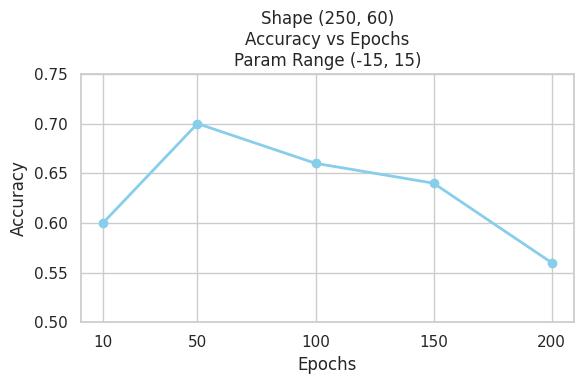

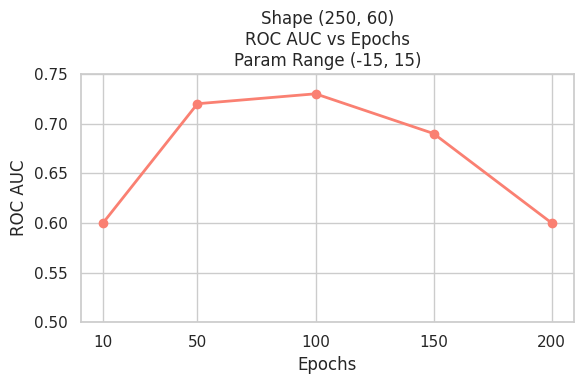

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Data
epochs = [10, 50, 100, 150, 200]
accuracy = [0.6, 0.7, 0.66, 0.64, 0.56]
auc = [0.6, 0.72, 0.73, 0.69, 0.6]

sns.set(style="whitegrid")

# Accuracy
plt.figure(figsize=(6, 4))
plt.plot(epochs, accuracy, marker='o', color='skyblue', linewidth=2, label='Accuracy')
plt.title("Shape (250, 60)\nAccuracy vs Epochs\nParam Range (-15, 15)", fontsize=12)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.ylim(0.5, 0.75)
plt.xticks(epochs)
plt.grid(True)
plt.tight_layout()
plt.show()

# AUC
plt.figure(figsize=(6, 4))
plt.plot(epochs, auc, marker='o', color='salmon', linewidth=2, label='ROC AUC')
plt.title("Shape (250, 60)\nROC AUC vs Epochs\nParam Range (-15, 15)", fontsize=12)
plt.xlabel("Epochs")
plt.ylabel("ROC AUC")
plt.ylim(0.5, 0.75)
plt.xticks(epochs)
plt.grid(True)
plt.tight_layout()
plt.show()


# Experiment 3:
From the observations of our Exp 2, we deduced that the performance of model varies every time we retrain the model. 
Therefore in this experiment we have evaluated the best performance model: 
Shape (250, 60), parameter range (-15, 15) and max epochs (50) {Accuracy: 70%} and evaluate the variations in the model's performance. 

### First iteration 

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [60]
parameter_ranges = [(-15, 15)]
n_samples_per_class = 125
results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=50,
            tol=0.01,
            shuffle=True,
            verbose=True,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        start_time = time.time()
        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)
        end_time = time.time()
        training_time = end_time - start_time

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report,
            "training_time_sec": training_time
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))
        print(f"Training Time: {training_time:.2f} seconds")

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 60 Features ======

---- Run with parameters_range = (-15, 15) ----
Compiling training circuit on device 'cpu'...
Compilation took 2.1836 seconds.
Key Generation...
Key generation took 34.9384 seconds.
Training on encrypted data...
Iteration 0 took 45.07 seconds.
Iteration 1 took 39.76 seconds.
Iteration 2 took 40.65 seconds.
Iteration 3 took 40.51 seconds.
Iteration 4 took 40.17 seconds.
Iteration 5 took 39.39 seconds.
Iteration 6 took 39.02 seconds.
Iteration 7 took 39.95 seconds.
Iteration 8 took 40.06 seconds.
Iteration 9 took 39.39 seconds.
Iteration 10 took 39.90 seconds.
Iteration 11 took 39.72 seconds.
Iteration 12 took 39.40 seconds.
Iteration 13 took 39.97 seconds.
Iteration 14 took 40.22 seconds.
Iteration 15 took 39.97 seconds.
Iteration 16 took 40.07 seconds.
Iteration 17 took 39.77 seconds.
Iteration 18 took 41.00 seconds.
Iteration 19 took 39.25 seconds.
Iteration 20 took 39.18 seconds.
Iteration 21 took 39.35 seconds.
Iteration 22 took 40.00 seconds.
I

#### Save the model at 'fhe_directory'

In [9]:
from concrete.ml.deployment import FHEModelDev, FHEModelClient, FHEModelServer

fhe_directory = r'fhe_client_server_files_first'

dev = FHEModelDev(path_dir=fhe_directory, model=cml_sgd)
dev.save()

### Second iteration 

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [60]
parameter_ranges = [(-15, 15)]
n_samples_per_class = 125
results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=50,
            tol=0.01,
            shuffle=True,
            verbose=True,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        start_time = time.time()
        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)
        end_time = time.time()
        training_time = end_time - start_time

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report,
            "training_time_sec": training_time
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))
        print(f"Training Time: {training_time:.2f} seconds")

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 60 Features ======

---- Run with parameters_range = (-15, 15) ----
Compiling training circuit on device 'cpu'...
Compilation took 2.1698 seconds.
Key Generation...
Key generation took 34.4362 seconds.
Training on encrypted data...
Iteration 0 took 43.82 seconds.
Iteration 1 took 39.24 seconds.
Iteration 2 took 39.67 seconds.
Iteration 3 took 39.15 seconds.
Iteration 4 took 39.34 seconds.
Iteration 5 took 40.42 seconds.
Iteration 6 took 39.51 seconds.
Iteration 7 took 40.57 seconds.
Iteration 8 took 39.71 seconds.
Iteration 9 took 40.57 seconds.
Iteration 10 took 41.02 seconds.
Iteration 11 took 40.48 seconds.
Iteration 12 took 40.71 seconds.
Iteration 13 took 40.82 seconds.
Iteration 14 took 39.78 seconds.
Iteration 15 took 40.03 seconds.
Iteration 16 took 40.43 seconds.
Iteration 17 took 39.19 seconds.
Iteration 18 took 40.34 seconds.
Iteration 19 took 40.14 seconds.
Iteration 20 took 40.33 seconds.
Iteration 21 took 41.05 seconds.
Iteration 22 took 40.70 seconds.
I

In [4]:
from concrete.ml.deployment import FHEModelDev, FHEModelClient, FHEModelServer

fhe_directory = r'fhe_client_server_files_second'

dev = FHEModelDev(path_dir=fhe_directory, model=cml_sgd)
dev.save()

is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor


### Third iteration 

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [60]
parameter_ranges = [(-15, 15)]
n_samples_per_class = 125
results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=50,
            tol=0.01,
            shuffle=True,
            verbose=True,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        start_time = time.time()
        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)
        end_time = time.time()
        training_time = end_time - start_time

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report,
            "training_time_sec": training_time
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))
        print(f"Training Time: {training_time:.2f} seconds")

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 60 Features ======

---- Run with parameters_range = (-15, 15) ----
Compiling training circuit on device 'cpu'...
Compilation took 1.9670 seconds.
Key Generation...
Key generation took 40.9480 seconds.
Training on encrypted data...
Iteration 0 took 23.45 seconds.
Iteration 1 took 19.92 seconds.
Iteration 2 took 19.91 seconds.
Iteration 3 took 19.82 seconds.
Iteration 4 took 20.35 seconds.
Iteration 5 took 19.89 seconds.
Iteration 6 took 19.85 seconds.
Iteration 7 took 19.99 seconds.
Iteration 8 took 20.00 seconds.
Iteration 9 took 19.94 seconds.
Iteration 10 took 20.02 seconds.
Iteration 11 took 19.92 seconds.
Iteration 12 took 19.95 seconds.
Iteration 13 took 19.69 seconds.
Iteration 14 took 20.12 seconds.
Iteration 15 took 20.26 seconds.
Iteration 16 took 19.44 seconds.
Iteration 17 took 19.97 seconds.
Iteration 18 took 20.55 seconds.
Iteration 19 took 19.92 seconds.
Iteration 20 took 19.48 seconds.
Iteration 21 took 19.72 seconds.
Iteration 22 took 19.73 seconds.
I

In [8]:
from concrete.ml.deployment import FHEModelDev, FHEModelClient, FHEModelServer

fhe_directory = r'fhe_client_server_files_third'

dev = FHEModelDev(path_dir=fhe_directory, model=cml_sgd)
dev.save()

### Fourth iteration

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [60]
parameter_ranges = [(-15, 15)]
n_samples_per_class = 125
results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=50,
            tol=0.01,
            shuffle=True,
            verbose=True,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        start_time = time.time()
        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)
        end_time = time.time()
        training_time = end_time - start_time

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report,
            "training_time_sec": training_time
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))
        print(f"Training Time: {training_time:.2f} seconds")

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 60 Features ======

---- Run with parameters_range = (-15, 15) ----
Compiling training circuit on device 'cpu'...
Compilation took 1.9114 seconds.
Key Generation...
Key generation took 40.2891 seconds.
Training on encrypted data...
Iteration 0 took 24.80 seconds.
Iteration 1 took 20.10 seconds.
Iteration 2 took 20.01 seconds.
Iteration 3 took 20.23 seconds.
Iteration 4 took 20.60 seconds.
Iteration 5 took 21.20 seconds.
Iteration 6 took 20.42 seconds.
Iteration 7 took 20.23 seconds.
Iteration 8 took 20.48 seconds.
Iteration 9 took 20.30 seconds.
Iteration 10 took 20.20 seconds.
Iteration 11 took 20.24 seconds.
Iteration 12 took 20.46 seconds.
Iteration 13 took 20.48 seconds.
Iteration 14 took 20.85 seconds.
Iteration 15 took 20.70 seconds.
Iteration 16 took 20.40 seconds.
Iteration 17 took 20.03 seconds.
Iteration 18 took 20.61 seconds.
Iteration 19 took 20.49 seconds.
Iteration 20 took 20.25 seconds.
Iteration 21 took 20.30 seconds.
Iteration 22 took 20.44 seconds.
I

KeySetCache: miss, regenerating ./keycache/12265383969111426261


Confusion Matrix:
[[13 12]
 [17  8]]
Accuracy: 0.4200 | ROC AUC: 0.4560
Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.52      0.47        25
           1       0.40      0.32      0.36        25

    accuracy                           0.42        50
   macro avg       0.42      0.42      0.41        50
weighted avg       0.42      0.42      0.41        50

Training Time: 1067.17 seconds

==== Final Results ====
Features: 60 | Parameters: (-15, 15) | AUC: 0.4560 | Accuracy: 0.4200


In [4]:
from concrete.ml.deployment import FHEModelDev, FHEModelClient, FHEModelServer

fhe_directory = r'fhe_client_server_files_fourth'

dev = FHEModelDev(path_dir=fhe_directory, model=cml_sgd)
dev.save()

is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor


### Fifth iteration


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from concrete.ml.sklearn import SGDClassifier
from concrete.fhe import Configuration
import gc
import time

feature_counts = [60]
parameter_ranges = [(-15, 15)]
n_samples_per_class = 125
results = []

config = Configuration(
    enable_unsafe_features=True,
    use_insecure_key_cache=True,
    insecure_key_cache_location="./keycache",
    fhe_execution=True
)

def release_memory():
    gc.collect()
    time.sleep(2)

for feat_count in feature_counts:
    print(f"\n====== Using Top {feat_count} Features ======")

    top_features = feature_importance.head(feat_count)['feature'].tolist()
    X_selected = df[top_features]
    y = df['TARGET']

    target_1_indices = y[y == 1].index
    target_0_indices = y[y == 0].index

    target_1_sampled = np.random.choice(target_1_indices, size=n_samples_per_class, replace=False)
    target_0_sampled = np.random.choice(target_0_indices, size=n_samples_per_class, replace=False)

    balanced_indices = np.concatenate([target_1_sampled, target_0_sampled])
    np.random.shuffle(balanced_indices)

    X_balanced = X_selected.loc[balanced_indices]
    y_balanced = y.loc[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for i, param_range in enumerate(parameter_ranges, 1):
        print(f"\n---- Run with parameters_range = {param_range} ----")

        cml_sgd = SGDClassifier(
            n_bits=16,
            fit_encrypted=True,
            parameters_range=param_range,
            loss="log_loss",
            penalty="l2",
            alpha=0.01,
            fit_intercept=True,
            max_iter=50,
            tol=0.01,
            shuffle=True,
            verbose=True,
            random_state=42,
            learning_rate="adaptive",
            eta0=0.001,
            power_t=0.5,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            class_weight="balanced",
            warm_start=False,
            average=False,
        )

        start_time = time.time()
        cml_sgd.fit(X_train_scaled, y_train, fhe="execute")
        cml_sgd.compile(X_train_scaled, configuration=config)
        end_time = time.time()
        training_time = end_time - start_time

        y_pred_encrypted = cml_sgd.predict(X_test_scaled, fhe="execute")
        y_pred_encrypted_prob = cml_sgd.predict_proba(X_test_scaled, fhe="execute")

        conf_matrix = confusion_matrix(y_test, y_pred_encrypted)
        auc_score = roc_auc_score(y_test, y_pred_encrypted_prob[:, 1])
        acc_score = accuracy_score(y_test, y_pred_encrypted)
        class_report = classification_report(y_test, y_pred_encrypted, output_dict=True)

        results.append({
            "feature_count": feat_count,
            "parameters_range": param_range,
            "confusion_matrix": conf_matrix,
            "roc_auc": auc_score,
            "accuracy": acc_score,
            "classification_report": class_report,
            "training_time_sec": training_time
        })

        print("Confusion Matrix:")
        print(conf_matrix)
        print(f"Accuracy: {acc_score:.4f} | ROC AUC: {auc_score:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred_encrypted))
        print(f"Training Time: {training_time:.2f} seconds")

        release_memory()

print("\n==== Final Results ====")
for r in results:
    print(f"Features: {r['feature_count']} | Parameters: {r['parameters_range']} | AUC: {r['roc_auc']:.4f} | Accuracy: {r['accuracy']:.4f}")



====== Using Top 60 Features ======

---- Run with parameters_range = (-15, 15) ----
Compiling training circuit on device 'cpu'...
Compilation took 1.9222 seconds.
Key Generation...
Key generation took 40.1017 seconds.
Training on encrypted data...
Iteration 0 took 24.30 seconds.
Iteration 1 took 19.48 seconds.
Iteration 2 took 19.73 seconds.
Iteration 3 took 19.69 seconds.
Iteration 4 took 19.14 seconds.
Iteration 5 took 19.24 seconds.
Iteration 6 took 19.89 seconds.
Iteration 7 took 19.69 seconds.
Iteration 8 took 19.71 seconds.
Iteration 9 took 19.68 seconds.
Iteration 10 took 19.73 seconds.
Iteration 11 took 19.87 seconds.
Iteration 12 took 19.61 seconds.
Iteration 13 took 19.61 seconds.
Iteration 14 took 19.54 seconds.
Iteration 15 took 19.74 seconds.
Iteration 16 took 19.41 seconds.
Iteration 17 took 19.29 seconds.
Confusion Matrix:
[[ 9 16]
 [12 13]]
Accuracy: 0.4400 | ROC AUC: 0.4816
Classification Report:
              precision    recall  f1-score   support

           0    

In [4]:
from concrete.ml.deployment import FHEModelDev, FHEModelClient, FHEModelServer

fhe_directory = r'fhe_client_server_files_fifth'

dev = FHEModelDev(path_dir=fhe_directory, model=cml_sgd)
dev.save()

is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor


# Experiment 3 Observations: 

We evaluated the performance of the same model (preserving every paramter) for 5 iterations and observed the performance variation. 
1. Accuracy: Max 0.70, Min 0.42, Median 0.55
2. ROC AUC: Max 0.72, Min 0.45, Median 0.57 

### Box Plots for ROC AUC and Accuracy

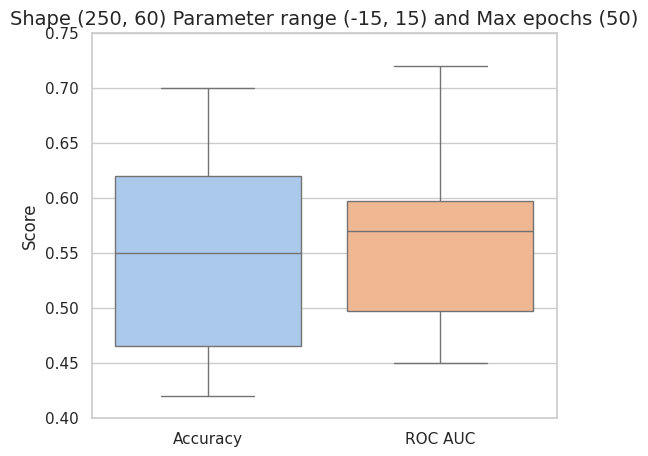

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data = {
    "Accuracy": [0.7, 0.64, 0.56, 0.54, 0.42, 0.44],
    "ROC AUC": [0.72, 0.6, 0.59, 0.55, 0.45, 0.48]
}

df = pd.DataFrame(data)

plt.figure(figsize=(6, 5))
sns.set(style="whitegrid")


sns.boxplot(data=df, palette="pastel")

plt.title("Shape (250, 60) Parameter range (-15, 15) and Max epochs (50)", fontsize=14)
plt.ylabel("Score")
plt.ylim(0.4, 0.75)

# Display
plt.show()


## Model deployment and inference boilerplate

In [5]:
from concrete.ml.deployment import FHEModelDev, FHEModelClient, FHEModelServer
client = FHEModelClient(path_dir=fhe_directory, key_dir=r"fhe_client_server_files_fifth")
serialized_evaluation_keys = client.get_serialized_evaluation_keys()

is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor
is_regressor


KeySetCache: miss, regenerating fhe_client_server_files_fifth/15922221039575784027


### Generate evaluation keys at client 

In [11]:
client = FHEModelClient(path_dir=fhe_directory, key_dir=r"fhe_client_server_files_first")
serialized_evaluation_keys = client.get_serialized_evaluation_keys()

KeySetCache: miss, regenerating fhe_client_server_files_first/7842054458795025465


In [ ]:
# Client encryption of scaled data

encrypted_data = client.quantize_encrypt_serialize(sample_scaled)

In [ ]:
# Server loads the model

server = FHEModelServer(path_dir=fhe_directory)
server.load()

In [ ]:
# Encrypted data sent to server along with evaluation keys

encrypted_result = server.run(encrypted_data, serialized_evaluation_keys)

In [ ]:
# Decrypt the encrypted result at client side
import numpy as np 

result = client.deserialize_decrypt_dequantize(encrypted_result)
print("Decrypted result:", result)

class_1_prob = result[0][1] if isinstance(result, np.ndarray) else result[1]

prediction = int(class_1_prob > 0.5)

print("Final prediction (0 or 1):", prediction)